In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from zipfile import ZipFile
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Ensemble
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, StackingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, silhouette_score, davies_bouldin_score
)

print("✅ All libraries imported!")

✅ All libraries imported!


In [3]:
df = pd.read_csv("/kaggle/input/datasets/dakshmahera22/dataset-week3/Country-data.csv")

print(df.shape)
df.head()

(167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


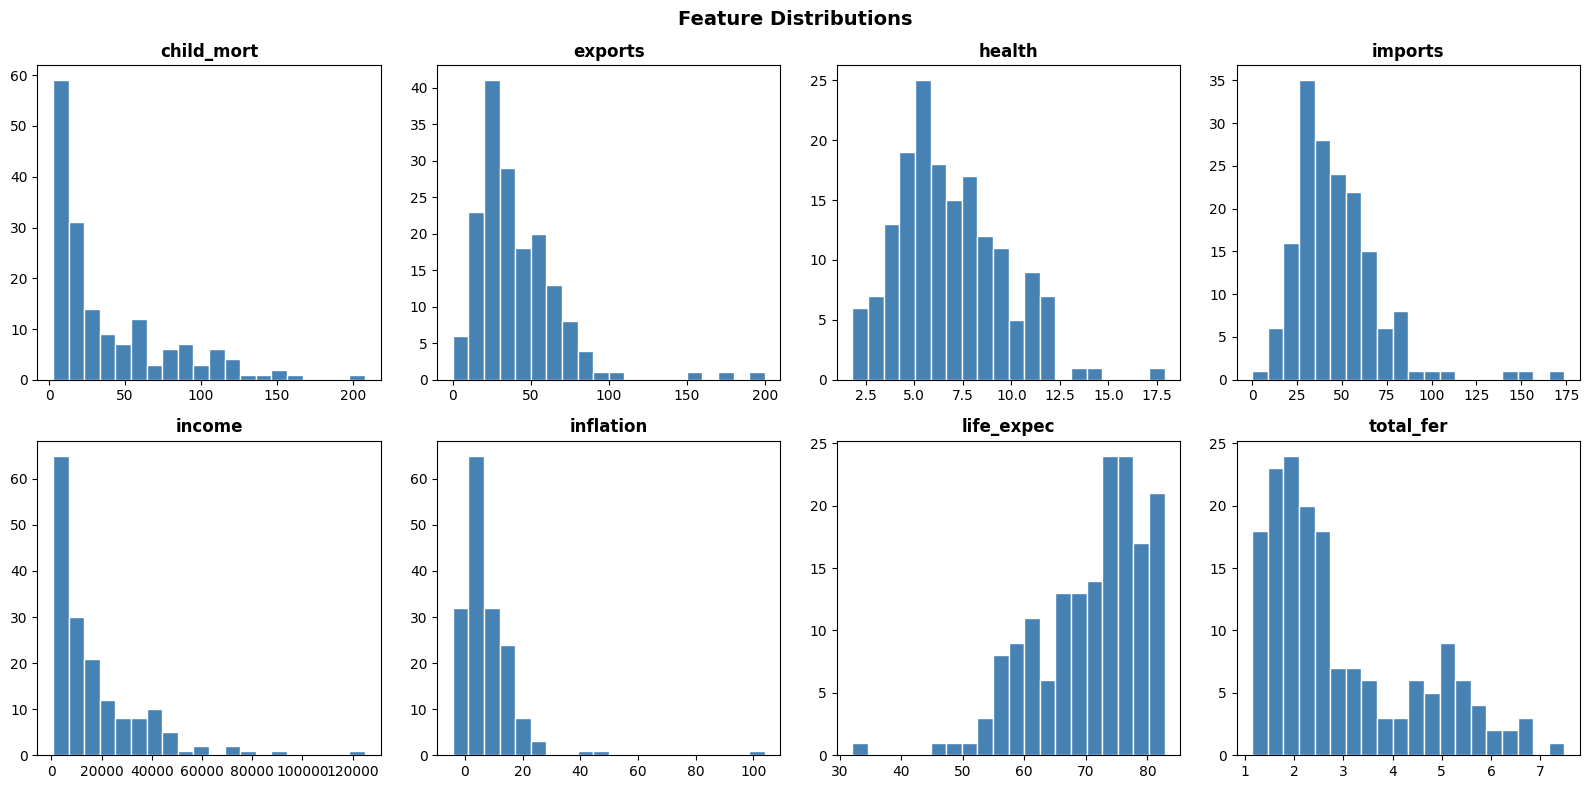

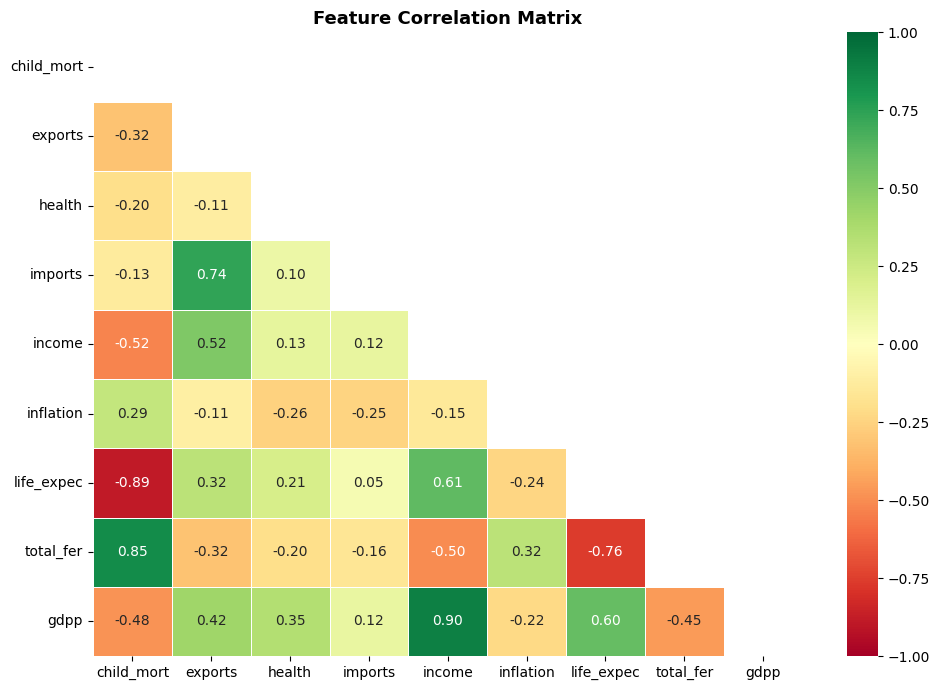

📌 Key: child_mort ↔ total_fer (strong +ve)  |  life_expec ↔ child_mort (strong -ve)


In [4]:
# ── EDA: Distribution + Correlation ──
features = ['child_mort','exports','health','imports',
            'income','inflation','life_expec','total_fer']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Feature Distributions", fontsize=14, fontweight='bold')
for i, col in enumerate(features):
    axes[i//4][i%4].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i//4][i%4].set_title(col, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 7))
corr = df[features + ['gdpp']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("📌 Key: child_mort ↔ total_fer (strong +ve)  |  life_expec ↔ child_mort (strong -ve)")

In [5]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None

Missing Values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Statistical Summary:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [6]:
median_gdpp = df["gdpp"].median()

df["High_Value"] = np.where(df["gdpp"] >= median_gdpp, 1, 0)

df["High_Value"].value_counts()

High_Value
1    84
0    83
Name: count, dtype: int64

In [7]:
X = df.drop(["country", "gdpp", "High_Value"], axis=1)

y = df["High_Value"]

print(X.shape)

(167, 8)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1:", f1_score(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_prob))

Accuracy: 0.7941176470588235
Precision: 0.7777777777777778
Recall: 0.8235294117647058
F1: 0.8
ROC-AUC: 0.9031141868512111


In [11]:
# Random Forest  ← now using X_train_scaled (bug fix)
rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)
rf.fit(X_train_scaled, y_train)   # ✅ was X_train before

rf_pred = rf.predict(X_test_scaled)
rf_prob = rf.predict_proba(X_test_scaled)[:, 1]

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1       :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))
print(classification_report(y_test, rf_pred))

Accuracy : 0.8823529411764706
Precision: 0.8421052631578947
Recall   : 0.9411764705882353
F1       : 0.8888888888888888
ROC-AUC  : 0.9221453287197232
              precision    recall  f1-score   support

           0       0.93      0.82      0.88        17
           1       0.84      0.94      0.89        17

    accuracy                           0.88        34
   macro avg       0.89      0.88      0.88        34
weighted avg       0.89      0.88      0.88        34



In [12]:
# XGBoost  ← now using X_train_scaled (bug fix)
xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8,
                    random_state=42, eval_metric="logloss", verbosity=0)
xgb.fit(X_train_scaled, y_train)   # ✅ was X_train before

xgb_pred = xgb.predict(X_test_scaled)
xgb_prob = xgb.predict_proba(X_test_scaled)[:, 1]

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1       :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_prob))
print(classification_report(y_test, xgb_pred))

Accuracy : 0.8823529411764706
Precision: 0.8095238095238095
Recall   : 1.0
F1       : 0.8947368421052632
ROC-AUC  : 0.889273356401384
              precision    recall  f1-score   support

           0       1.00      0.76      0.87        17
           1       0.81      1.00      0.89        17

    accuracy                           0.88        34
   macro avg       0.90      0.88      0.88        34
weighted avg       0.90      0.88      0.88        34



=== Naive Bayes ===
              precision    recall  f1-score   support

           0       0.77      0.59      0.67        17
           1       0.67      0.82      0.74        17

    accuracy                           0.71        34
   macro avg       0.72      0.71      0.70        34
weighted avg       0.72      0.71      0.70        34


Best K for KNN = 11
=== KNN ===
              precision    recall  f1-score   support

           0       0.75      0.71      0.73        17
           1       0.72      0.76      0.74        17

    accuracy                           0.74        34
   macro avg       0.74      0.74      0.74        34
weighted avg       0.74      0.74      0.74        34

=== SVM ===
              precision    recall  f1-score   support

           0       0.93      0.82      0.88        17
           1       0.84      0.94      0.89        17

    accuracy                           0.88        34
   macro avg       0.89      0.88      0.88        34
weighted 

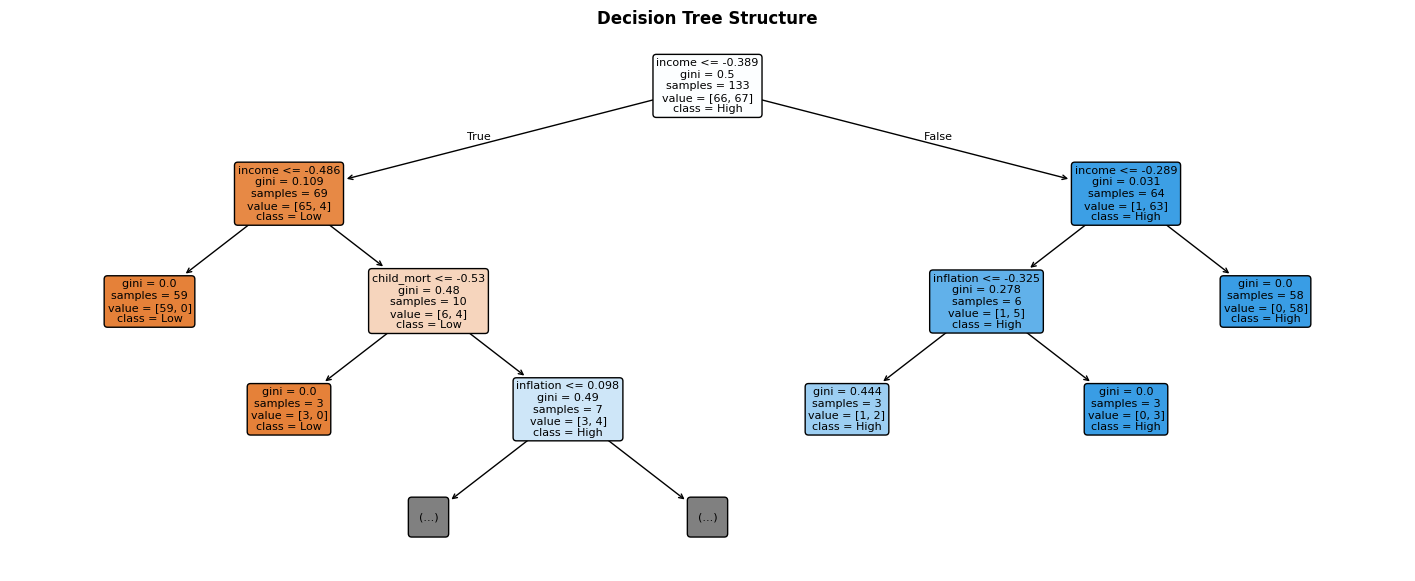

In [13]:
# ── Naive Bayes ──
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
nb_pred = nb.predict(X_test_scaled)
nb_prob = nb.predict_proba(X_test_scaled)[:, 1]
print("=== Naive Bayes ===")
print(classification_report(y_test, nb_pred))

# ── K-Nearest Neighbors (optimal K via CV) ──
k_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k),
            X_train_scaled, y_train, cv=5).mean() for k in range(1, 16)]
best_k = np.argmax(k_scores) + 1
print(f"\nBest K for KNN = {best_k}")

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
knn_prob = knn.predict_proba(X_test_scaled)[:, 1]
print("=== KNN ===")
print(classification_report(y_test, knn_pred))

# ── SVM ──
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)
svm_prob = svm.predict_proba(X_test_scaled)[:, 1]
print("=== SVM ===")
print(classification_report(y_test, svm_pred))

# ── Decision Tree ──
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=3, random_state=42)
dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)
print("=== Decision Tree ===")
print(classification_report(y_test, dt_pred))

plt.figure(figsize=(18, 7))
plot_tree(dt, feature_names=X.columns, class_names=['Low','High'],
          filled=True, rounded=True, max_depth=3, fontsize=8)
plt.title("Decision Tree Structure", fontweight='bold')
plt.show()

In [14]:
# ── AdaBoost ──
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=200, learning_rate=0.5, random_state=42
)
ada.fit(X_train_scaled, y_train)
ada_pred = ada.predict(X_test_scaled)
print("=== AdaBoost ===")
print(classification_report(y_test, ada_pred))

# ── Gradient Boosting ──
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                 max_depth=4, random_state=42)
gb.fit(X_train_scaled, y_train)
gb_pred = gb.predict(X_test_scaled)
print("=== Gradient Boosting ===")
print(classification_report(y_test, gb_pred))

# ── LightGBM ──
lgbm = LGBMClassifier(n_estimators=200, learning_rate=0.1,
                       max_depth=5, random_state=42, verbose=-1)
lgbm.fit(X_train_scaled, y_train)
lgbm_pred = lgbm.predict(X_test_scaled)
lgbm_prob = lgbm.predict_proba(X_test_scaled)[:, 1]
print("=== LightGBM ===")
print(classification_report(y_test, lgbm_pred))

# ── Stacking ──
estimators = [
    ('lr',   LogisticRegression(max_iter=500, random_state=42)),
    ('rf',   RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb',  XGBClassifier(n_estimators=100, eval_metric='logloss',
                            random_state=42, verbosity=0)),
]
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=500),
    cv=5
)
stack.fit(X_train_scaled, y_train)
stack_pred = stack.predict(X_test_scaled)
print("=== Stacking ===")
print(classification_report(y_test, stack_pred))

=== AdaBoost ===
              precision    recall  f1-score   support

           0       1.00      0.71      0.83        17
           1       0.77      1.00      0.87        17

    accuracy                           0.85        34
   macro avg       0.89      0.85      0.85        34
weighted avg       0.89      0.85      0.85        34

=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.86      0.71      0.77        17
           1       0.75      0.88      0.81        17

    accuracy                           0.79        34
   macro avg       0.80      0.79      0.79        34
weighted avg       0.80      0.79      0.79        34

=== LightGBM ===
              precision    recall  f1-score   support

           0       1.00      0.76      0.87        17
           1       0.81      1.00      0.89        17

    accuracy                           0.88        34
   macro avg       0.90      0.88      0.88        34
weighted avg  

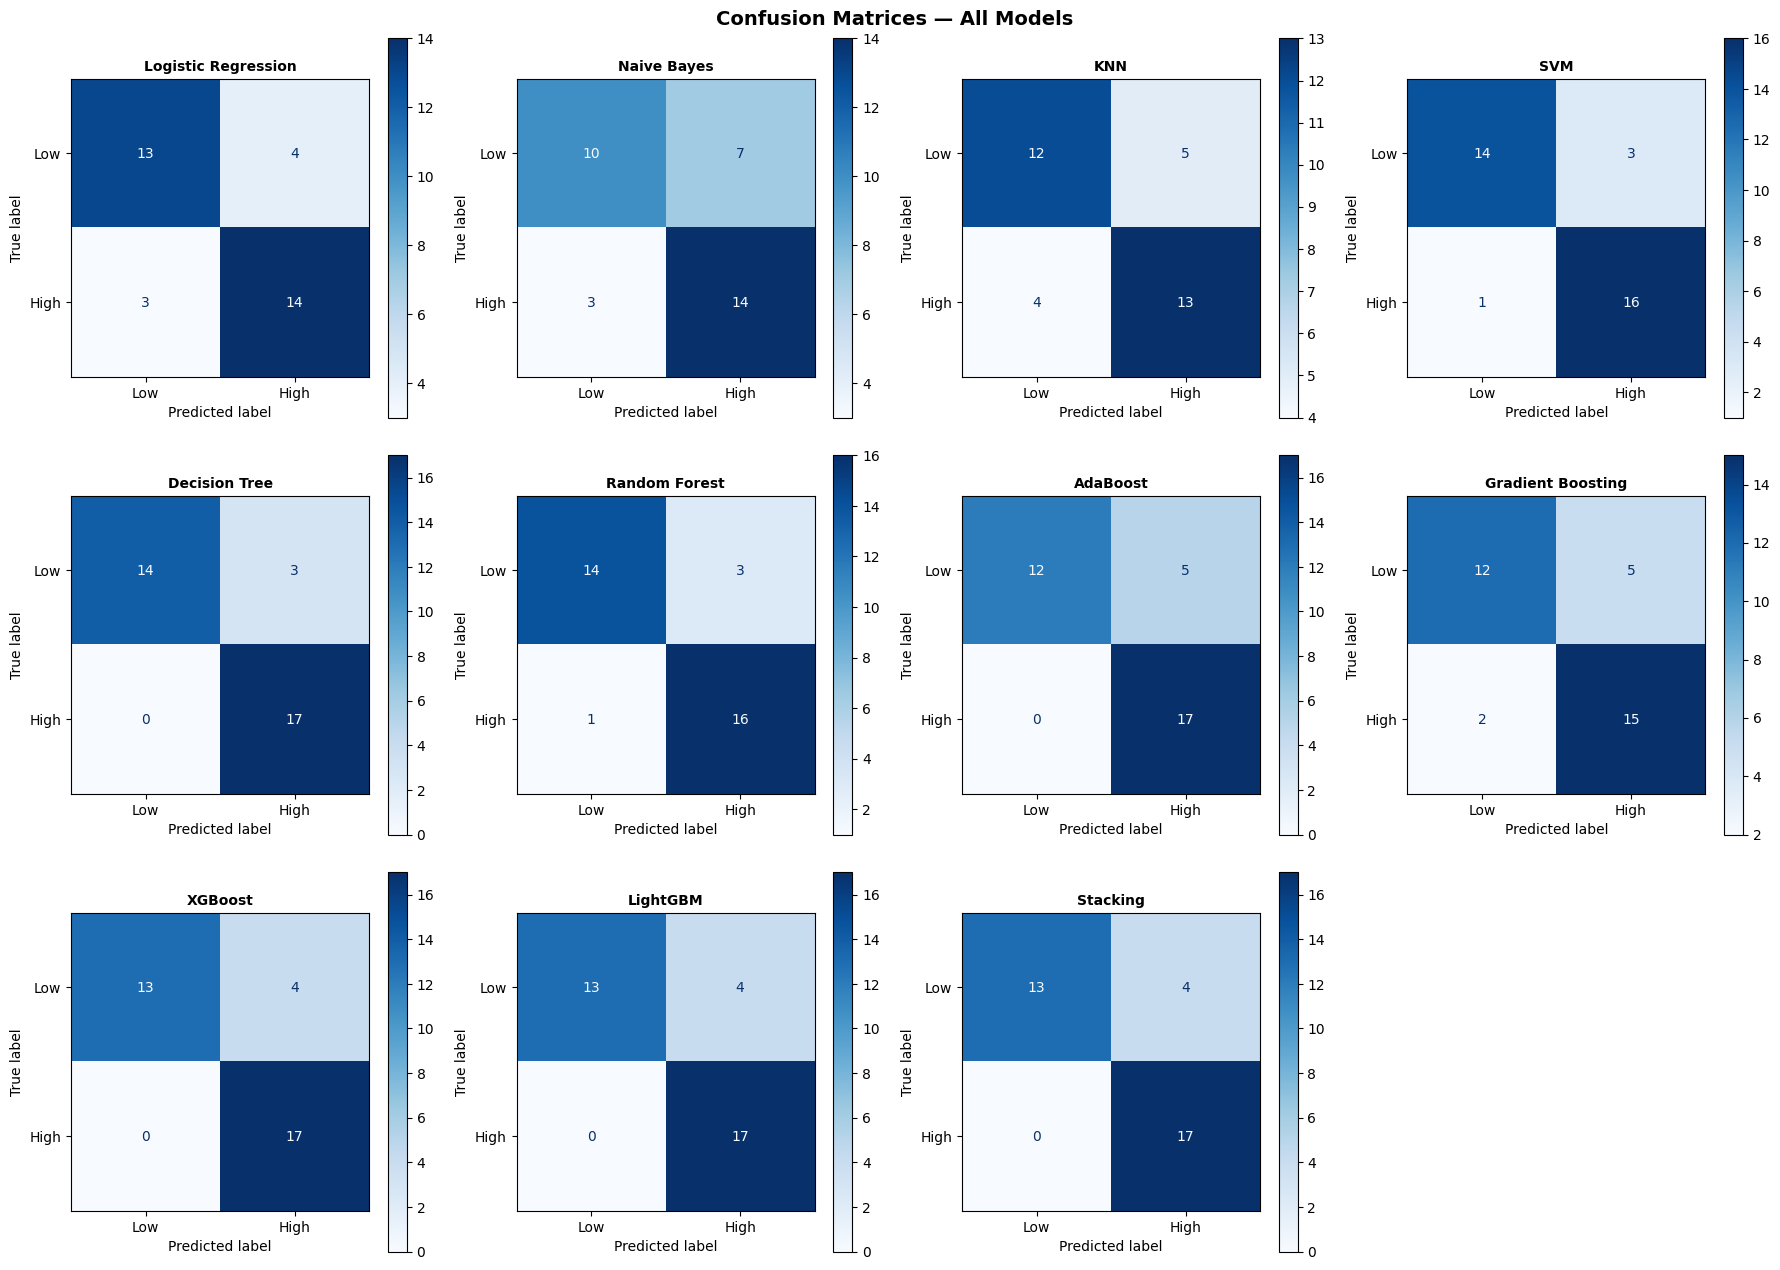

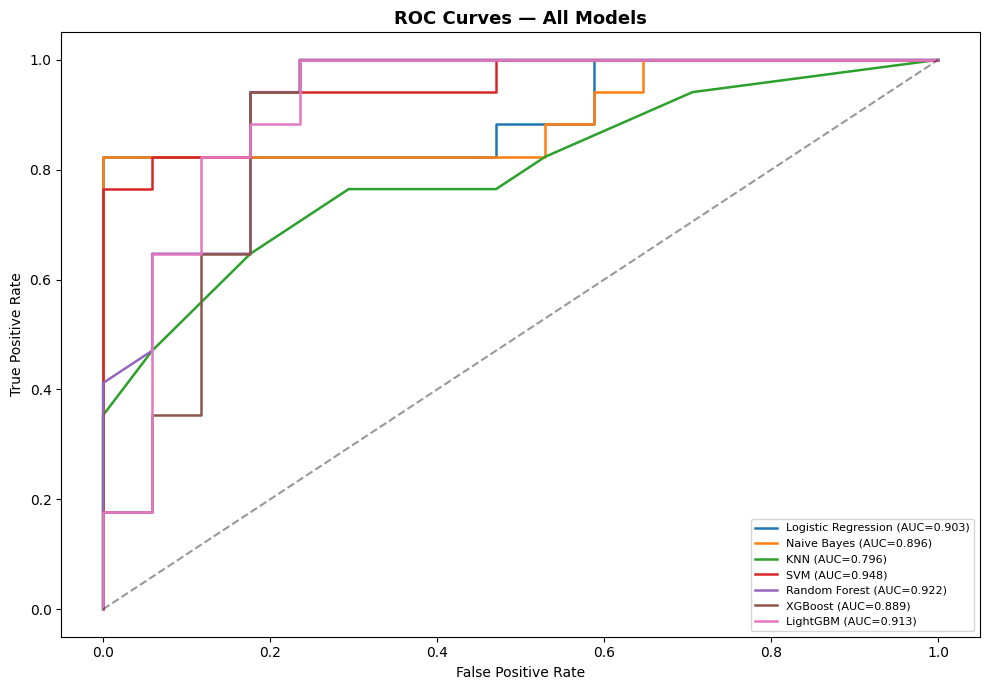

,Model,Accuracy,F1,ROC-AUC
0,Decision Tree,91.18,0.9189,-
1,SVM,88.24,0.8889,0.9481
2,Random Forest,88.24,0.8889,0.9221
3,Stacking,88.24,0.8947,-
4,LightGBM,88.24,0.8947,0.9135
5,XGBoost,88.24,0.8947,0.8893
6,AdaBoost,85.29,0.8718,-
7,Logistic Regression,79.41,0.8000,0.9031
8,Gradient Boosting,79.41,0.8108,-
9,KNN,73.53,0.7429,0.7958



🥇 Best Model: Decision Tree  (91.18%)


In [15]:
# ── All predictions dictionary ──
all_models = {
    "Logistic Regression":  (lr_pred,  lr_prob),
    "Naive Bayes":          (nb_pred,  nb_prob),
    "KNN":                  (knn_pred, knn_prob),
    "SVM":                  (svm_pred, svm_prob),
    "Decision Tree":        (dt_pred,  None),
    "Random Forest":        (rf_pred,  rf_prob),
    "AdaBoost":             (ada_pred, None),
    "Gradient Boosting":    (gb_pred,  None),
    "XGBoost":              (xgb_pred, xgb_prob),
    "LightGBM":             (lgbm_pred,lgbm_prob),
    "Stacking":             (stack_pred,None),
}

# ── Confusion Matrices (grid) ──
fig, axes = plt.subplots(3, 4, figsize=(18, 13))
axes = axes.flatten()
for i, (name, (pred, _)) in enumerate(all_models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, display_labels=['Low','High'],
        cmap='Blues', ax=axes[i]
    )
    axes[i].set_title(name, fontsize=10, fontweight='bold')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── ROC Curves ──
plt.figure(figsize=(10, 7))
for name, (_, prob) in all_models.items():
    if prob is not None:
        fpr, tpr, _ = roc_curve(y_test, prob)
        auc = roc_auc_score(y_test, prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=1.8)
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models", fontsize=13, fontweight='bold')
plt.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

# ── Summary Leaderboard ──
summary = pd.DataFrame([
    {
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, pred) * 100, 2),
        "F1": round(f1_score(y_test, pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, prob), 4) if prob is not None else "-"
    }
    for name, (pred, prob) in all_models.items()
]).sort_values("Accuracy", ascending=False).reset_index(drop=True)

display(summary)
print(f"\n🥇 Best Model: {summary.iloc[0]['Model']}  ({summary.iloc[0]['Accuracy']}%)")

5-Fold Cross-Validation Results:
  Logistic Regression      : 0.9100 ± 0.0724
  Random Forest            : 0.9174 ± 0.0754
  XGBoost                  : 0.9396 ± 0.0382
  LightGBM                 : 0.9470 ± 0.0305
  SVM                      : 0.8801 ± 0.0425


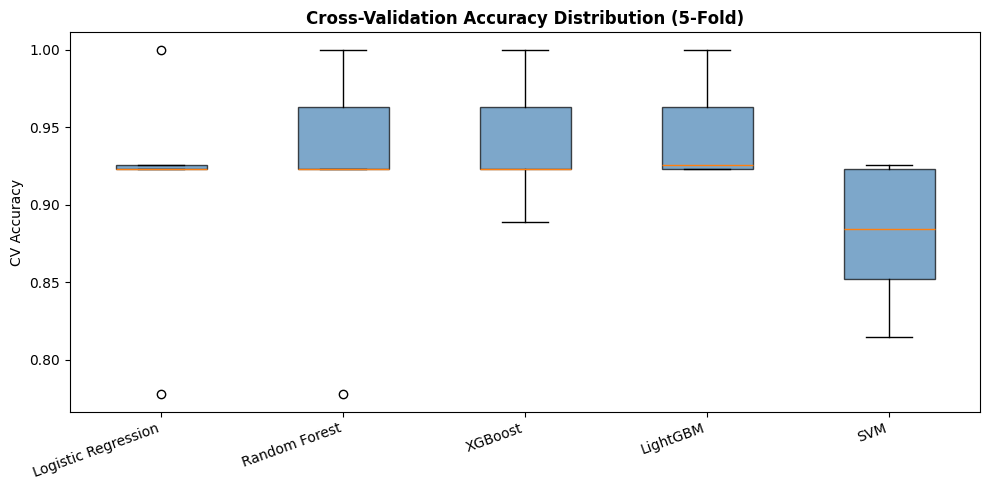

In [17]:
# ── 5-Fold Cross-Validation on key models ──
cv_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=100, eval_metric='logloss',
                                          random_state=42, verbosity=0),
    "LightGBM":            LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    "SVM":                 SVC(kernel='rbf', C=10, random_state=42),
}

print("5-Fold Cross-Validation Results:")
cv_results = {}
for name, m in cv_models.items():
    scores = cross_val_score(m, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f"  {name:25s}: {scores.mean():.4f} ± {scores.std():.4f}")

# Plot CV results
plt.figure(figsize=(10, 5))
plt.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.7))
plt.xticks(rotation=20, ha='right')
plt.ylabel("CV Accuracy")
plt.title("Cross-Validation Accuracy Distribution (5-Fold)", fontweight='bold')
plt.tight_layout()
plt.show()

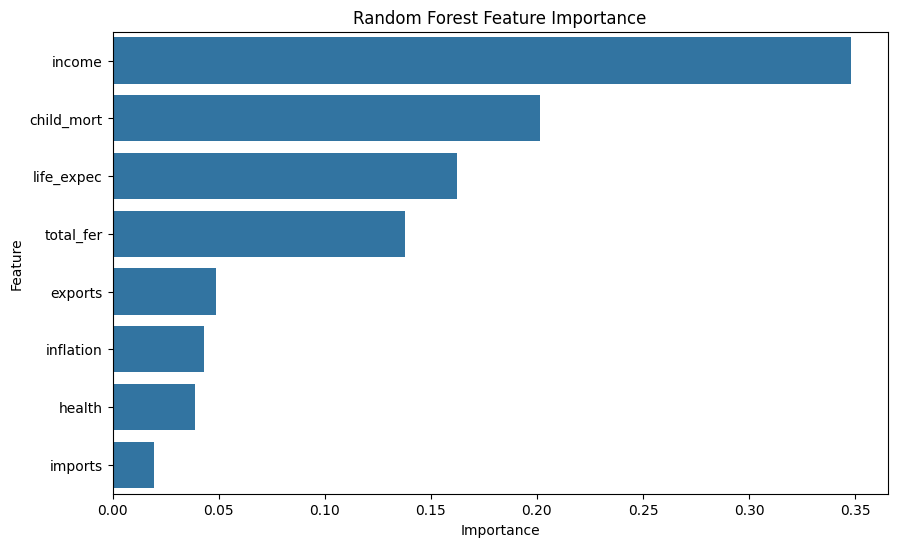

,Feature,Importance
4,income,0.347875
0,child_mort,0.201670
6,life_expec,0.162445
7,total_fer,0.137708
1,exports,0.048539
5,inflation,0.043333
2,health,0.038717
3,imports,0.019712


In [14]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)
plt.title("Random Forest Feature Importance")
plt.show()

importance

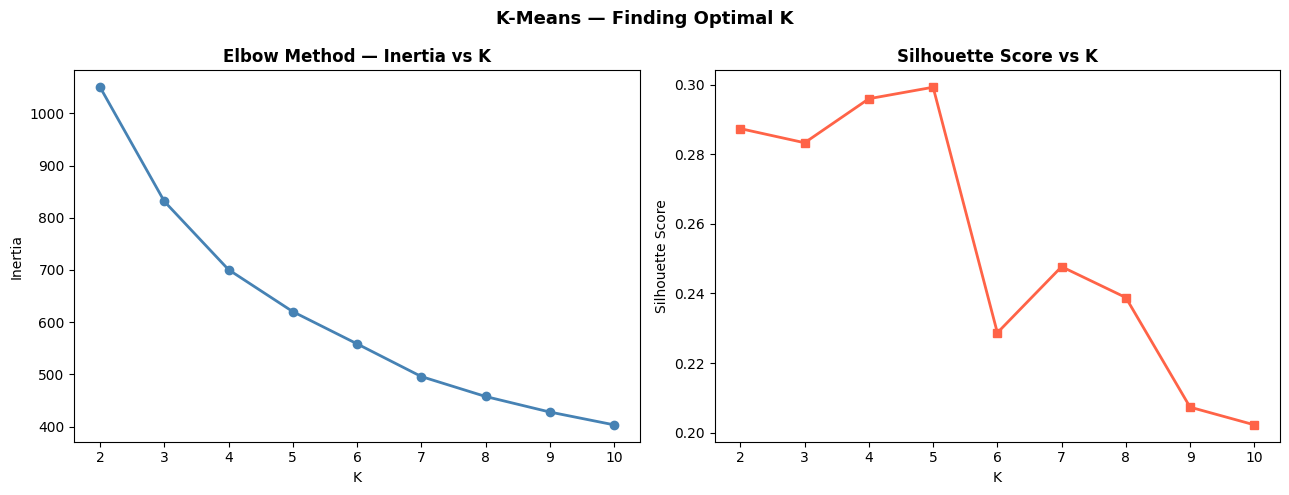

📌 Optimal K = 5  (Silhouette = 0.2993)
Silhouette Score: 0.2992594995920442
Davies-Bouldin Index: 0.8717934121836723


In [18]:
cluster_features = df.drop(["country", "High_Value"], axis=1)
scaled_cluster = StandardScaler().fit_transform(cluster_features)

# ── Elbow Method ──
inertias, sil_scores = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(scaled_cluster, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs K', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), sil_scores, marker='s', color='tomato', linewidth=2)
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')

plt.suptitle('K-Means — Finding Optimal K', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Apply optimal K ──
best_k = list(K_range)[np.argmax(sil_scores)]
print(f"📌 Optimal K = {best_k}  (Silhouette = {max(sil_scores):.4f})")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["KMeans_Cluster"] = kmeans.fit_predict(scaled_cluster)
print("Silhouette Score:", silhouette_score(scaled_cluster, df["KMeans_Cluster"]))
print("Davies-Bouldin Index:", davies_bouldin_score(scaled_cluster, df["KMeans_Cluster"]))

In [19]:
cluster_summary = df.groupby(
    "KMeans_Cluster"
).mean(numeric_only=True)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,High_Value
KMeans_Cluster,,,,,,,,,,
0,21.614286,40.976060,6.169048,47.518642,12801.071429,7.618857,73.004762,2.277619,6581.809524,0.523810
1,90.793617,29.661915,6.462553,43.680851,3870.702128,9.951809,59.212766,4.974043,1900.255319,0.106383
2,4.133333,176.000000,6.793333,156.666667,64033.333333,2.468000,81.433333,1.380000,57566.666667,1.000000
3,5.181250,46.118750,9.088437,40.584375,44021.875000,2.513844,80.081250,1.788437,42118.750000,1.000000
4,130.000000,25.300000,5.070000,17.400000,5150.000000,104.000000,60.500000,5.840000,2330.000000,0.000000


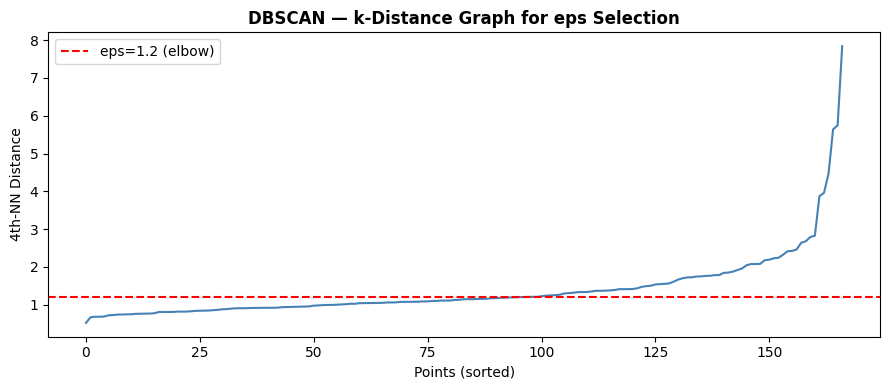

📌 DBSCAN → 3 clusters, 50 noise/outlier points
DBSCAN_Cluster
 1    76
-1    50
 0    23
 2    18
Name: count, dtype: int64

🔍 Outlier Countries:
['Angola', 'Bahrain', 'Belarus', 'Belgium', 'Brunei', 'Burundi', 'Central African Republic', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Haiti', 'Iraq', 'Ireland', 'Jordan', 'Kiribati', 'Kuwait', 'Lesotho', 'Liberia', 'Libya', 'Luxembourg', 'Malta', 'Mauritania', 'Micronesia, Fed. Sts.', 'Moldova', 'Mongolia', 'Myanmar', 'Nigeria', 'Norway', 'Oman', 'Pakistan', 'Qatar', 'Rwanda', 'Saudi Arabia', 'Seychelles', 'Sierra Leone', 'Singapore', 'Solomon Islands', 'South Africa', 'Sudan', 'Switzerland', 'Timor-Leste', 'Togo', 'Tonga', 'Turkmenistan', 'United Arab Emirates', 'United States', 'Venezuela', 'Vietnam']


In [20]:
# ── k-Distance Graph to find correct eps ──
nbrs = NearestNeighbors(n_neighbors=4).fit(scaled_cluster)
distances, _ = nbrs.kneighbors(scaled_cluster)
k_dist = np.sort(distances[:, 3])

plt.figure(figsize=(9, 4))
plt.plot(k_dist, color='steelblue', linewidth=1.5)
plt.axhline(y=1.2, color='red', linestyle='--', label='eps=1.2 (elbow)')
plt.title('DBSCAN — k-Distance Graph for eps Selection', fontweight='bold')
plt.xlabel('Points (sorted)'); plt.ylabel('4th-NN Distance')
plt.legend(); plt.tight_layout(); plt.show()

# ── Apply DBSCAN with corrected eps ──
dbscan = DBSCAN(eps=1.2, min_samples=4)   # ← was eps=1.5, now gives 3 clusters
df["DBSCAN_Cluster"] = dbscan.fit_predict(scaled_cluster)

n_clusters = len(set(df["DBSCAN_Cluster"])) - (1 if -1 in df["DBSCAN_Cluster"].values else 0)
n_noise    = (df["DBSCAN_Cluster"] == -1).sum()
print(f"📌 DBSCAN → {n_clusters} clusters, {n_noise} noise/outlier points")
print(df["DBSCAN_Cluster"].value_counts())

print("\n🔍 Outlier Countries:")
print(df[df["DBSCAN_Cluster"] == -1]["country"].tolist())

In [21]:
# ── K-Medoids (PAM Algorithm — pure NumPy, no extra install needed) ──
class KMedoids:
    def __init__(self, n_clusters=3, max_iter=300, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state

    def fit_predict(self, X):
        from scipy.spatial.distance import cdist
        rng = np.random.default_rng(self.random_state)
        X = np.array(X)
        D = cdist(X, X)
        medoids = rng.choice(len(X), self.n_clusters, replace=False)
        for _ in range(self.max_iter):
            labels = np.argmin(D[:, medoids], axis=1)
            new_medoids = []
            for k in range(self.n_clusters):
                members = np.where(labels == k)[0]
                if len(members) == 0:
                    new_medoids.append(medoids[k])
                else:
                    costs = D[np.ix_(members, members)].sum(axis=1)
                    new_medoids.append(members[np.argmin(costs)])
            new_medoids = np.array(new_medoids)
            if np.all(new_medoids == medoids):
                break
            medoids = new_medoids
        self.medoid_indices_ = medoids
        self.labels_ = labels
        return labels

kmed = KMedoids(n_clusters=3, random_state=42)
df["KMedoids_Cluster"] = kmed.fit_predict(scaled_cluster)

print("K-Medoids Silhouette Score :", silhouette_score(scaled_cluster, df["KMedoids_Cluster"]))
print("K-Medoids Davies-Bouldin   :", davies_bouldin_score(scaled_cluster, df["KMedoids_Cluster"]))
print("\n🎯 Medoid Countries (most representative per cluster):")
for i, idx in enumerate(kmed.medoid_indices_):
    print(f"  Cluster {i}: {df.loc[idx, 'country']}")

K-Medoids Silhouette Score : 0.2646747532960616
K-Medoids Davies-Bouldin   : 1.291306937262897

🎯 Medoid Countries (most representative per cluster):
  Cluster 0: Ghana
  Cluster 1: Tunisia
  Cluster 2: Finland


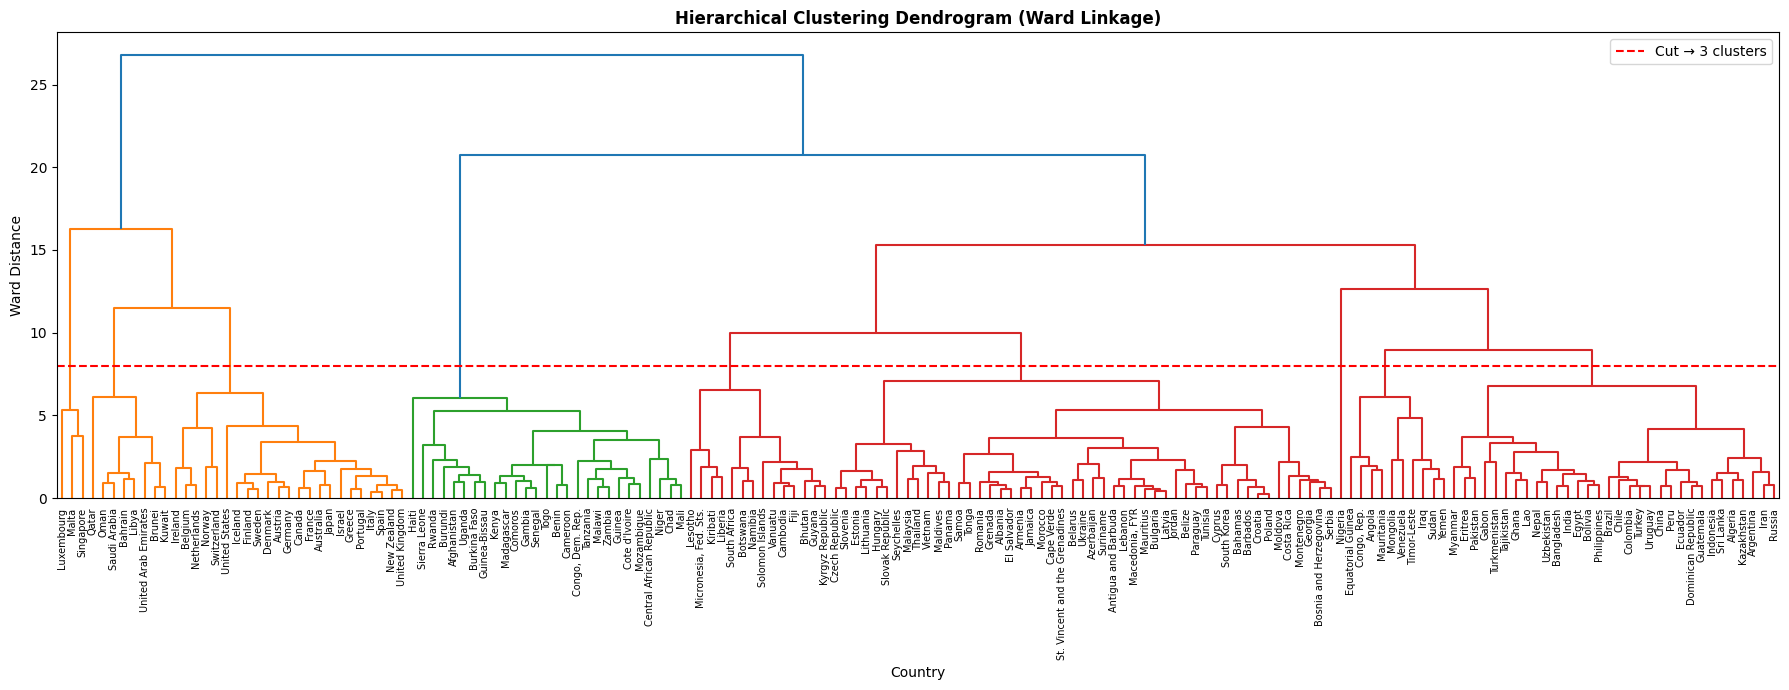

Hierarchical Silhouette Score: 0.24563001303300652
Hierarchical Davies-Bouldin  : 1.299788958694555


In [22]:
# ── Dendrogram ──
Z = linkage(scaled_cluster, method='ward')
plt.figure(figsize=(18, 7))
from scipy.cluster.hierarchy import dendrogram
dendrogram(Z, labels=df['country'].values, leaf_rotation=90, leaf_font_size=7)
plt.axhline(y=8, color='red', linestyle='--', label='Cut → 3 clusters')
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontweight='bold')
plt.xlabel('Country'); plt.ylabel('Ward Distance')
plt.legend(); plt.tight_layout(); plt.show()

# ── Agglomerative Clustering ──
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
df["Hier_Cluster"] = agg.fit_predict(scaled_cluster)

print("Hierarchical Silhouette Score:", silhouette_score(scaled_cluster, df["Hier_Cluster"]))
print("Hierarchical Davies-Bouldin  :", davies_bouldin_score(scaled_cluster, df["Hier_Cluster"]))

,Silhouette ↑,Davies-Bouldin ↓,Clusters
K-Means,0.2993,0.8718,5.0
K-Medoids,0.2647,1.2913,3.0
DBSCAN,0.3696,0.8404,3.0
Hierarchical,0.2456,1.2998,3.0


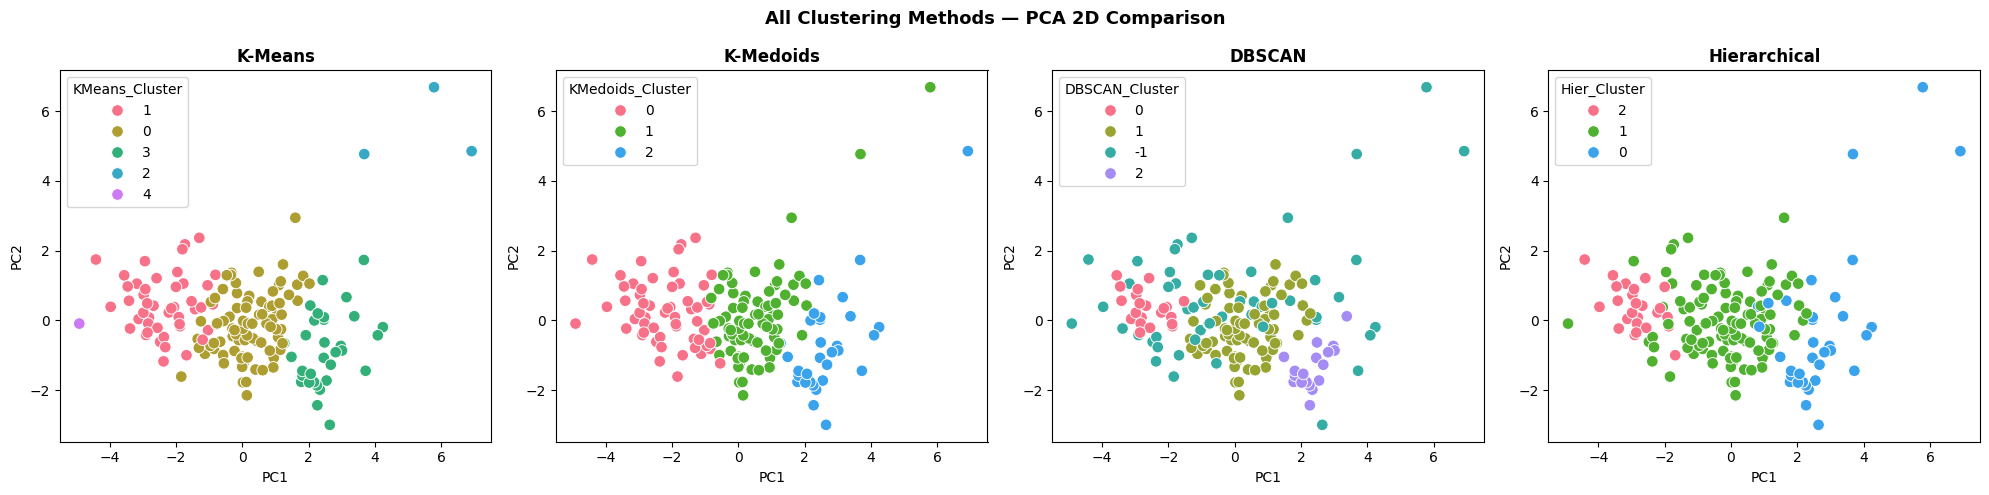

In [23]:
# ── Clustering Evaluation Summary ──
db_valid = df["DBSCAN_Cluster"] != -1

eval_summary = pd.DataFrame({
    "K-Means": {
        "Silhouette ↑": silhouette_score(scaled_cluster, df["KMeans_Cluster"]),
        "Davies-Bouldin ↓": davies_bouldin_score(scaled_cluster, df["KMeans_Cluster"]),
        "Clusters": df["KMeans_Cluster"].nunique()
    },
    "K-Medoids": {
        "Silhouette ↑": silhouette_score(scaled_cluster, df["KMedoids_Cluster"]),
        "Davies-Bouldin ↓": davies_bouldin_score(scaled_cluster, df["KMedoids_Cluster"]),
        "Clusters": df["KMedoids_Cluster"].nunique()
    },
    "DBSCAN": {
        "Silhouette ↑": silhouette_score(scaled_cluster[db_valid], df.loc[db_valid,"DBSCAN_Cluster"]),
        "Davies-Bouldin ↓": davies_bouldin_score(scaled_cluster[db_valid], df.loc[db_valid,"DBSCAN_Cluster"]),
        "Clusters": n_clusters
    },
    "Hierarchical": {
        "Silhouette ↑": silhouette_score(scaled_cluster, df["Hier_Cluster"]),
        "Davies-Bouldin ↓": davies_bouldin_score(scaled_cluster, df["Hier_Cluster"]),
        "Clusters": 3
    }
}).T.round(4)

display(eval_summary)

# Visualize all 4 clustering results side-by-side
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(scaled_cluster)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
cluster_cols = ["KMeans_Cluster","KMedoids_Cluster","DBSCAN_Cluster","Hier_Cluster"]
titles = ["K-Means","K-Medoids","DBSCAN","Hierarchical"]
for ax, col, title in zip(axes, cluster_cols, titles):
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1],
                    hue=df[col].astype(str), palette='husl', ax=ax, s=70)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.suptitle('All Clustering Methods — PCA 2D Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

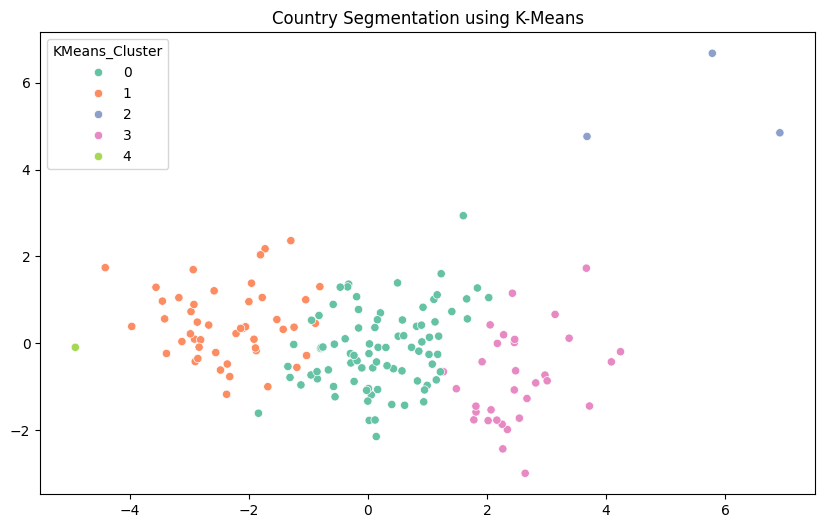

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(
    scaled_cluster
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=pca_features[:,0],
    y=pca_features[:,1],
    hue=df["KMeans_Cluster"],
    palette="Set2"
)

plt.title("Country Segmentation using K-Means")
plt.show()

In [25]:
high_value_countries = df[
    df["High_Value"] == 1
][["country","income","gdpp"]]

print("Total High Value Countries:")
print(len(high_value_countries))

display(
    high_value_countries
    .sort_values("gdpp", ascending=False)
    .head(20)
)

Total High Value Countries:
84


,country,income,gdpp
91,Luxembourg,91700,105000
114,Norway,62300,87800
145,Switzerland,55500,74600
123,Qatar,125000,70300
44,Denmark,44000,58000
144,Sweden,42900,52100
7,Australia,41400,51900
110,Netherlands,45500,50300
73,Ireland,45700,48700
159,United States,49400,48400


In [27]:
# ── Data-Driven Final Insights ──
best_model = summary.iloc[0]
best_cluster = eval_summary["Silhouette ↑"].idxmax()

print("=" * 60)
print("  CUSTOMER INTELLIGENCE SYSTEM — KEY FINDINGS")
print("=" * 60)

print(f"\n🥇 Best Classifier  : {best_model['Model']} ({best_model['Accuracy']}% accuracy)")
print(f"🔵 Best Clustering  : {best_cluster} (Silhouette={eval_summary.loc[best_cluster,'Silhouette ↑']:.4f})")

top_feat = pd.Series(rf.feature_importances_, index=X.columns).idxmax()
print(f"📌 Top Predictor    : {top_feat} (most important for High-Value prediction)")

high_val = df[df["High_Value"] == 1]
low_val  = df[df["High_Value"] == 0]
print(f"\n📊 High-Value Countries: {len(high_val)}")
print(f"   Avg Income : {high_val['income'].mean():,.0f}")
print(f"   Avg GDPP   : {high_val['gdpp'].mean():,.0f}")
print(f"\n📊 Low-Value Countries : {len(low_val)}")
print(f"   Avg Income : {low_val['income'].mean():,.0f}")
print(f"   Avg GDPP   : {low_val['gdpp'].mean():,.0f}")

outlier_countries = df[df["DBSCAN_Cluster"] == -1]["country"].tolist()
print(f"\n🔍 DBSCAN Outliers ({len(outlier_countries)} countries — atypical socioeconomics):")
print(f"   {outlier_countries[:8]}")

print("\n💡 Business Actions:")
print("   • Target High-Value cluster for premium products/services")
print("   • DBSCAN outliers need custom strategy (not fit standard segments)")
print(f"  • Use {best_model['Model']} for new country classification")
print("\n✅ Analysis Complete!")

  CUSTOMER INTELLIGENCE SYSTEM — KEY FINDINGS

🥇 Best Classifier  : Decision Tree (91.18% accuracy)
🔵 Best Clustering  : DBSCAN (Silhouette=0.3696)
📌 Top Predictor    : income (most important for High-Value prediction)

📊 High-Value Countries: 84
   Avg Income : 29,744
   Avg GDPP   : 23,898

📊 Low-Value Countries : 83
   Avg Income : 4,394
   Avg GDPP   : 1,898

🔍 DBSCAN Outliers (50 countries — atypical socioeconomics):
   ['Angola', 'Bahrain', 'Belarus', 'Belgium', 'Brunei', 'Burundi', 'Central African Republic', 'Congo, Dem. Rep.']

💡 Business Actions:
   • Target High-Value cluster for premium products/services
   • DBSCAN outliers need custom strategy (not fit standard segments)
  • Use Decision Tree for new country classification

✅ Analysis Complete!
